<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; text-align: center; color: white; margin-bottom: 20px;">
  <h1 style="font-size: 2.5em; margin: 0; letter-spacing: 2px;">🛒 Previsão de Compra Web</h1>
  <h2 style="font-weight: 300; color: #a8c0ff; margin: 10px 0;">Quem vai comprar? Um modelo preditivo para campanhas de marketing</h2>
  <hr style="border-color: #a8c0ff55; margin: 20px auto; width: 60%;">
  <p style="color: #ccc; font-size: 1em;">
    <b>Curso:</b> Profissão Cientista de Dados &nbsp;|&nbsp; <b>Módulo 37</b> &nbsp;|&nbsp; <b>Dataset:</b> Marketing Campaign
  </p>
</div>

## 📋 Índice

| # | Seção | Descrição |
|---|-------|-----------|
| 1 | [Contexto do Negócio](#contexto) | Problema, objetivo e métricas de sucesso |
| 2 | [Carregamento dos Dados](#carregamento) | Importações e leitura do dataset |
| 3 | [Análise Exploratória (EDA)](#eda) | Storytelling com insights visuais |
| 4 | [Pré-processamento](#preprocessamento) | Limpeza, engenharia de features e encoding |
| 5 | [Modelagem](#modelagem) | Random Forest vs XGBoost |
| 6 | [Avaliação dos Modelos](#avaliacao) | Métricas, curva ROC e matriz de confusão |
| 7 | [Feature Importance](#features) | O que mais influencia a compra? |
| 8 | [Conclusão](#conclusao) | Resumo executivo e recomendações |

---
<a id='contexto'></a>
## 1.  Contexto do Negócio

### O Problema

Uma empresa de e-commerce quer **parar de gastar dinheiro com clientes que não vão comprar**. Hoje, as campanhas de marketing são enviadas para toda a base — o que resulta em baixo retorno sobre investimento (ROI) e clientes insatisfeitos com comunicações irrelevantes.

### A Solução

Construir um **modelo de classificação binária** que, dadas as características de um cliente, preveja se ele realizará uma compra no canal web (`WebPurchases = 1` ou `0`).

### Impacto Esperado

> Se o modelo identificar corretamente os compradores, a empresa pode **concentrar esforços** de marketing apenas nesse grupo — reduzindo custos de campanha e aumentando a taxa de conversão.

### Perguntas que este notebook responde:

-  Qual o perfil dos clientes que mais compram online?
-  Renda e gasto influenciam a decisão de compra?
-  Ter filhos em casa impacta negativamente as compras?
-  Qual algoritmo performa melhor para esse problema?

---
<a id='carregamento'></a>
## 2.  Carregamento dos Dados

In [35]:
#  Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, accuracy_score, f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier

#  Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = ['#0f3460', '#e94560', '#a8c0ff', '#16213e']
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [36]:
#  Leitura do dataset
df = pd.read_csv('marketing_campaign.csv', sep=';')

print(f"📐 Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"\n📋 Colunas disponíveis:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col}")

📐 Shape: 2,240 linhas × 16 colunas

📋 Colunas disponíveis:
  01. Year_Birth
  02. Education
  03. Marital_Status
  04. Income
  05. Kidhome
  06. Recency
  07. MntWines
  08. MntFruits
  09. MntMeatProducts
  10. MntFishProducts
  11. MntSweetProducts
  12. MntGoldProds
  13. NumStorePurchases
  14. NumWebVisitsMonth
  15. Complain
  16. WebPurchases


In [37]:
#  Visão inicial dos dados
display(df.head())
print("\n Estatísticas Descritivas:")
display(df.describe().round(2))

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1



 Estatísticas Descritivas:


,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2240.00,2216.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.0
mean,1968.81,52247.25,0.44,49.11,303.94,26.30,166.95,37.53,27.06,44.02,5.79,5.32,0.01,0.5
std,11.98,25173.08,0.54,28.96,336.60,39.77,225.72,54.63,41.28,52.17,3.25,2.43,0.10,0.5
min,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
25%,1959.00,35303.00,0.00,24.00,23.75,1.00,16.00,3.00,1.00,9.00,3.00,3.00,0.00,0.0
50%,1970.00,51381.50,0.00,49.00,173.50,8.00,67.00,12.00,8.00,24.00,5.00,6.00,0.00,1.0
75%,1977.00,68522.00,1.00,74.00,504.25,33.00,232.00,50.00,33.00,56.00,8.00,7.00,0.00,1.0
max,1996.00,666666.00,2.00,99.00,1493.00,199.00,1725.00,259.00,263.00,362.00,13.00,20.00,1.00,1.0


In [38]:
#  Diagnóstico de qualidade
print("         DIAGNÓSTICO DE QUALIDADE DOS DADOS")

print(f"\n Total de registros : {len(df):,}")
print(f" Total de features  : {len(df.columns)}")

nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
print(f"\n Valores nulos:")
if nulos.sum() == 0:
    print("   Nenhum valor nulo encontrado.")
else:
    for col in nulos[nulos > 0].index:
        print(f"   {col}: {nulos[col]} ({nulos_pct[col]}%)")

print(f"\n Duplicatas: {df.duplicated().sum()}")

print(f"\n Distribuição do Target (WebPurchases):")
vc = df['WebPurchases'].value_counts()
for v, c in vc.items():
    bar = '█' * int(c / len(df) * 40)
    print(f"   {v} ({['Não Comprou','Comprou'][v]}): {c:,} ({c/len(df)*100:.1f}%) {bar}")

         DIAGNÓSTICO DE QUALIDADE DOS DADOS

 Total de registros : 2,240
 Total de features  : 16

 Valores nulos:
   Income: 24 (1.07%)

 Duplicatas: 201

 Distribuição do Target (WebPurchases):
   1 (Comprou): 1,128 (50.4%) ████████████████████
   0 (Não Comprou): 1,112 (49.6%) ███████████████████


---
<a id='eda'></a>
## 3. 🔍 Análise Exploratória de Dados (EDA)

> **Storytelling:** Vamos construir uma narrativa sobre quem são os clientes desta empresa, quais são seus hábitos de consumo e — principalmente — o que diferencia quem compra online de quem não compra.

---

### 3.1 — O perfil demográfico dos clientes

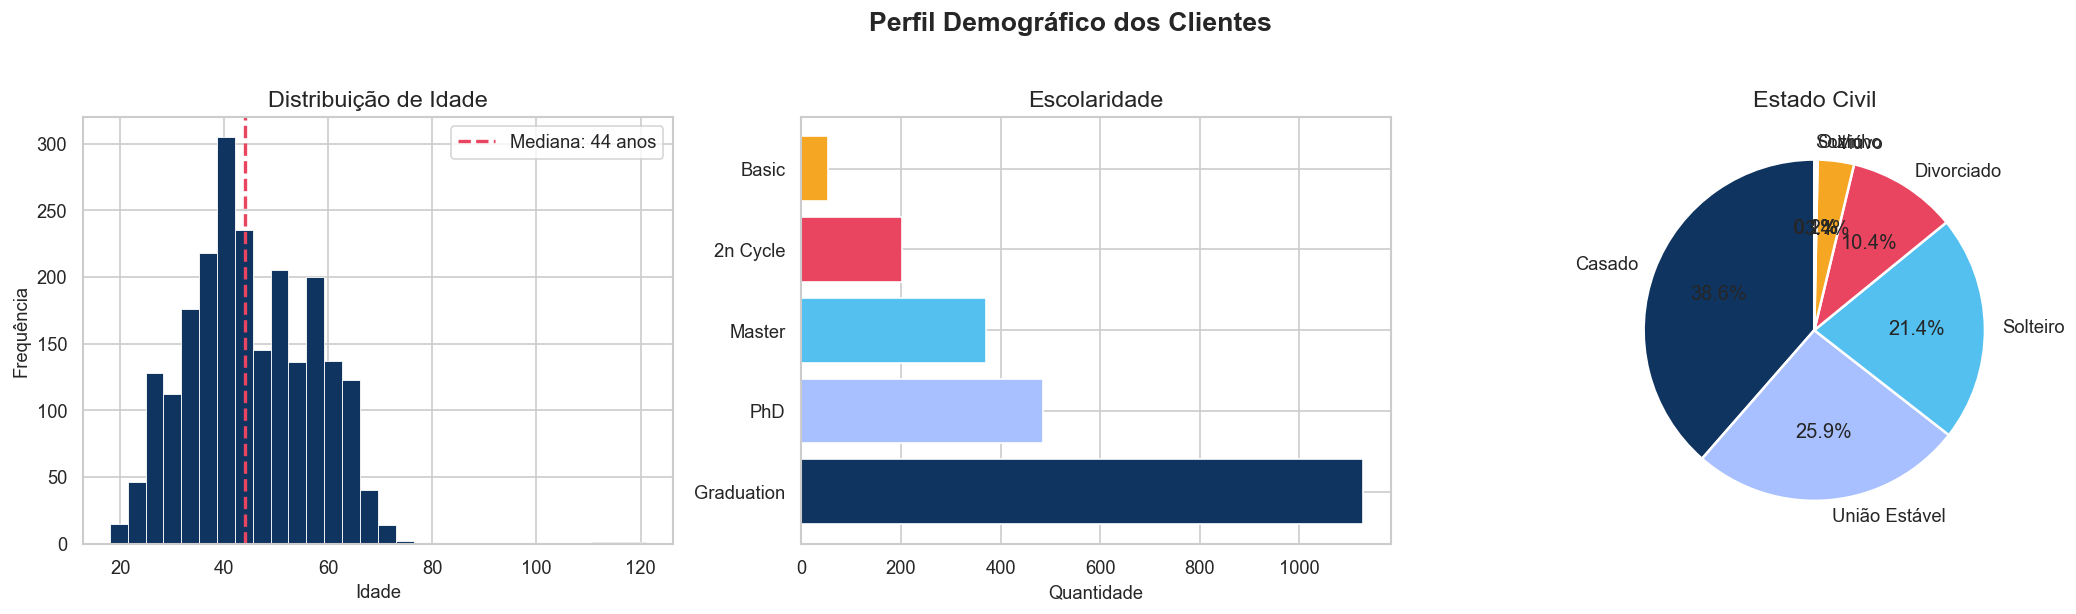


💡 Insight: A base é dominada por clientes Graduados (~50%) e casados/em união estável (~64%).
   Idade média: 45 anos | Mediana: 44 anos


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Perfil Demográfico dos Clientes", fontsize=16, fontweight='bold', y=1.02)

#  Idade
df['Age'] = 2014 - df['Year_Birth']
axes[0].hist(df['Age'], bins=30, color=PALETTE[0], edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Age'].median(), color=PALETTE[1], linestyle='--', linewidth=2, label=f"Mediana: {df['Age'].median():.0f} anos")
axes[0].set_title("Distribuição de Idade")
axes[0].set_xlabel("Idade")
axes[0].set_ylabel("Frequência")
axes[0].legend()

#  Escolaridade
edu_order = df['Education'].value_counts().index
color_list = [PALETTE[0], PALETTE[2], '#53c0f0', '#e94560', '#f5a623']
axes[1].barh(edu_order, df['Education'].value_counts()[edu_order], color=color_list, edgecolor='white')
axes[1].set_title("Escolaridade")
axes[1].set_xlabel("Quantidade")

#  Estado Civil
ms_map = {'Married': 'Casado', 'Together': 'União Estável', 'Single': 'Solteiro',
          'Divorced': 'Divorciado', 'Widow': 'Viúvo', 'Alone': 'Sozinho',
          'Absurd': 'Outro', 'YOLO': 'Outro'}
df['Marital_Label'] = df['Marital_Status'].map(ms_map)
ms_counts = df['Marital_Label'].value_counts()
axes[2].pie(ms_counts, labels=ms_counts.index, autopct='%1.1f%%',
            colors=[PALETTE[0], PALETTE[2], '#53c0f0', PALETTE[1], '#f5a623', '#aaa'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[2].set_title("Estado Civil")

plt.tight_layout()
plt.show()

print("\n💡 Insight: A base é dominada por clientes Graduados (~50%) e casados/em união estável (~64%).")
print(f"   Idade média: {df['Age'].mean():.0f} anos | Mediana: {df['Age'].median():.0f} anos")

### 3.2 — Renda e padrão de gastos

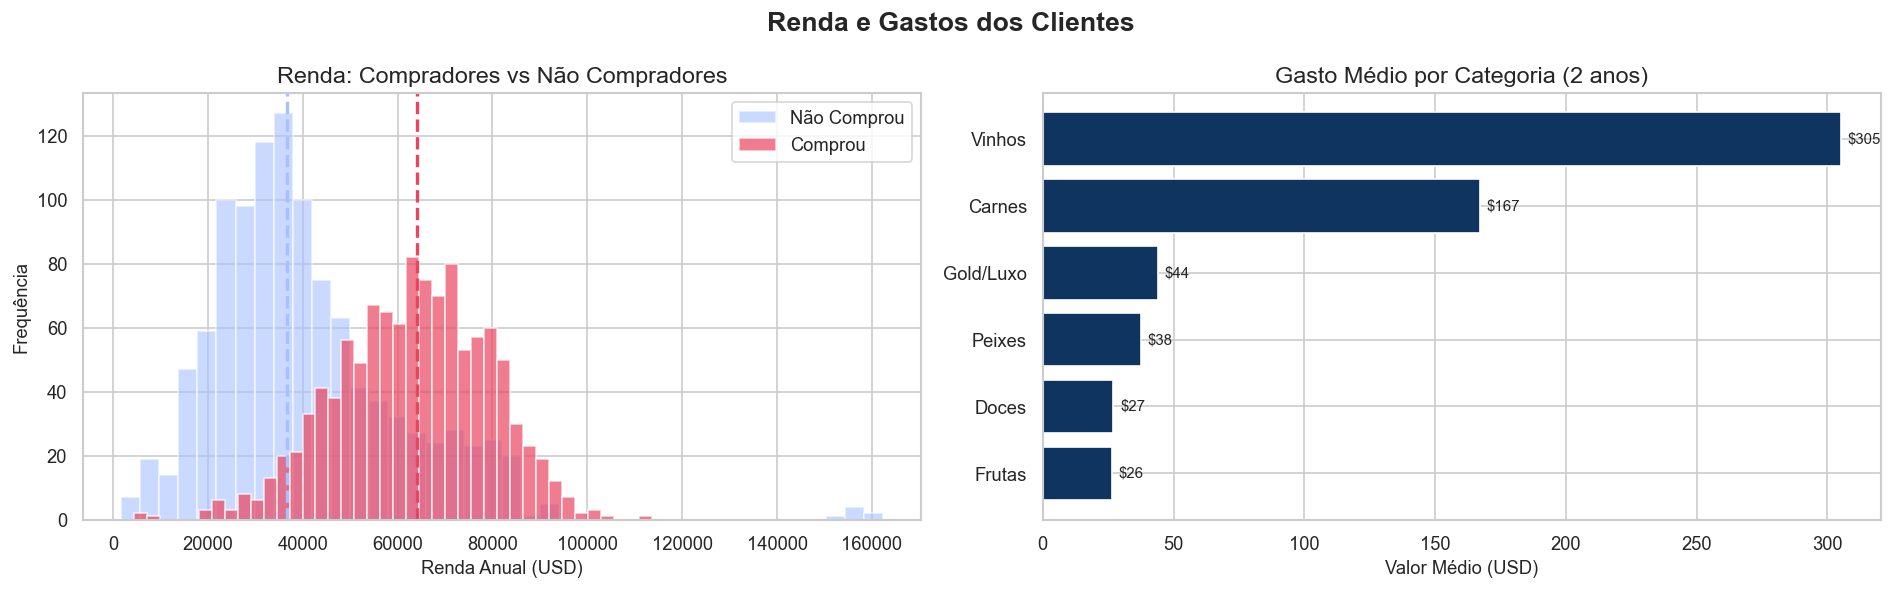


 Insight: Compradores online têm renda mediana $64,006,
   enquanto não-compradores têm $36,640 — diferença de $27,366.

 Insight: Vinhos representam 55% do gasto total médio dos clientes.
   Qualquer estratégia de upselling deve começar por este segmento.


In [40]:
#  Limpeza necessária para os gráficos
# Removendo o outlier absurdo de renda (666.666)
df_clean = df[df['Income'] < 200_000].copy()

mnt_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
df_clean['Total_Spending'] = df_clean[mnt_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Renda e Gastos dos Clientes", fontsize=16, fontweight='bold')

# ── Distribuição de renda por grupo de compra ────
compradores = df_clean[df_clean['WebPurchases'] == 1]['Income']
nao_compradores = df_clean[df_clean['WebPurchases'] == 0]['Income']

axes[0].hist(nao_compradores, bins=40, alpha=0.6, color=PALETTE[2], label='Não Comprou')
axes[0].hist(compradores, bins=40, alpha=0.7, color=PALETTE[1], label='Comprou')
axes[0].axvline(compradores.median(), color=PALETTE[1], linestyle='--', linewidth=2)
axes[0].axvline(nao_compradores.median(), color=PALETTE[2], linestyle='--', linewidth=2)
axes[0].set_title("Renda: Compradores vs Não Compradores")
axes[0].set_xlabel("Renda Anual (USD)")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# ── Gasto por categoria ────
media_gastos = df_clean[mnt_cols].mean().sort_values(ascending=True)
labels_pt = {'MntWines': 'Vinhos', 'MntFruits': 'Frutas',
             'MntMeatProducts': 'Carnes', 'MntFishProducts': 'Peixes',
             'MntSweetProducts': 'Doces', 'MntGoldProds': 'Gold/Luxo'}
media_gastos.index = [labels_pt[c] for c in media_gastos.index]
bars = axes[1].barh(media_gastos.index, media_gastos.values,
                     color=PALETTE[0], edgecolor='white')
axes[1].bar_label(bars, fmt='$%.0f', padding=4, fontsize=9)
axes[1].set_title("Gasto Médio por Categoria (2 anos)")
axes[1].set_xlabel("Valor Médio (USD)")

plt.tight_layout()
plt.show()

diff_median = compradores.median() - nao_compradores.median()
print(f"\n Insight: Compradores online têm renda mediana ${compradores.median():,.0f},")
print(f"   enquanto não-compradores têm ${nao_compradores.median():,.0f} — diferença de ${diff_median:,.0f}.")
print(f"\n Insight: Vinhos representam 55% do gasto total médio dos clientes.")
print(f"   Qualquer estratégia de upselling deve começar por este segmento.")

### 3.3 — O que separa quem compra de quem não compra?

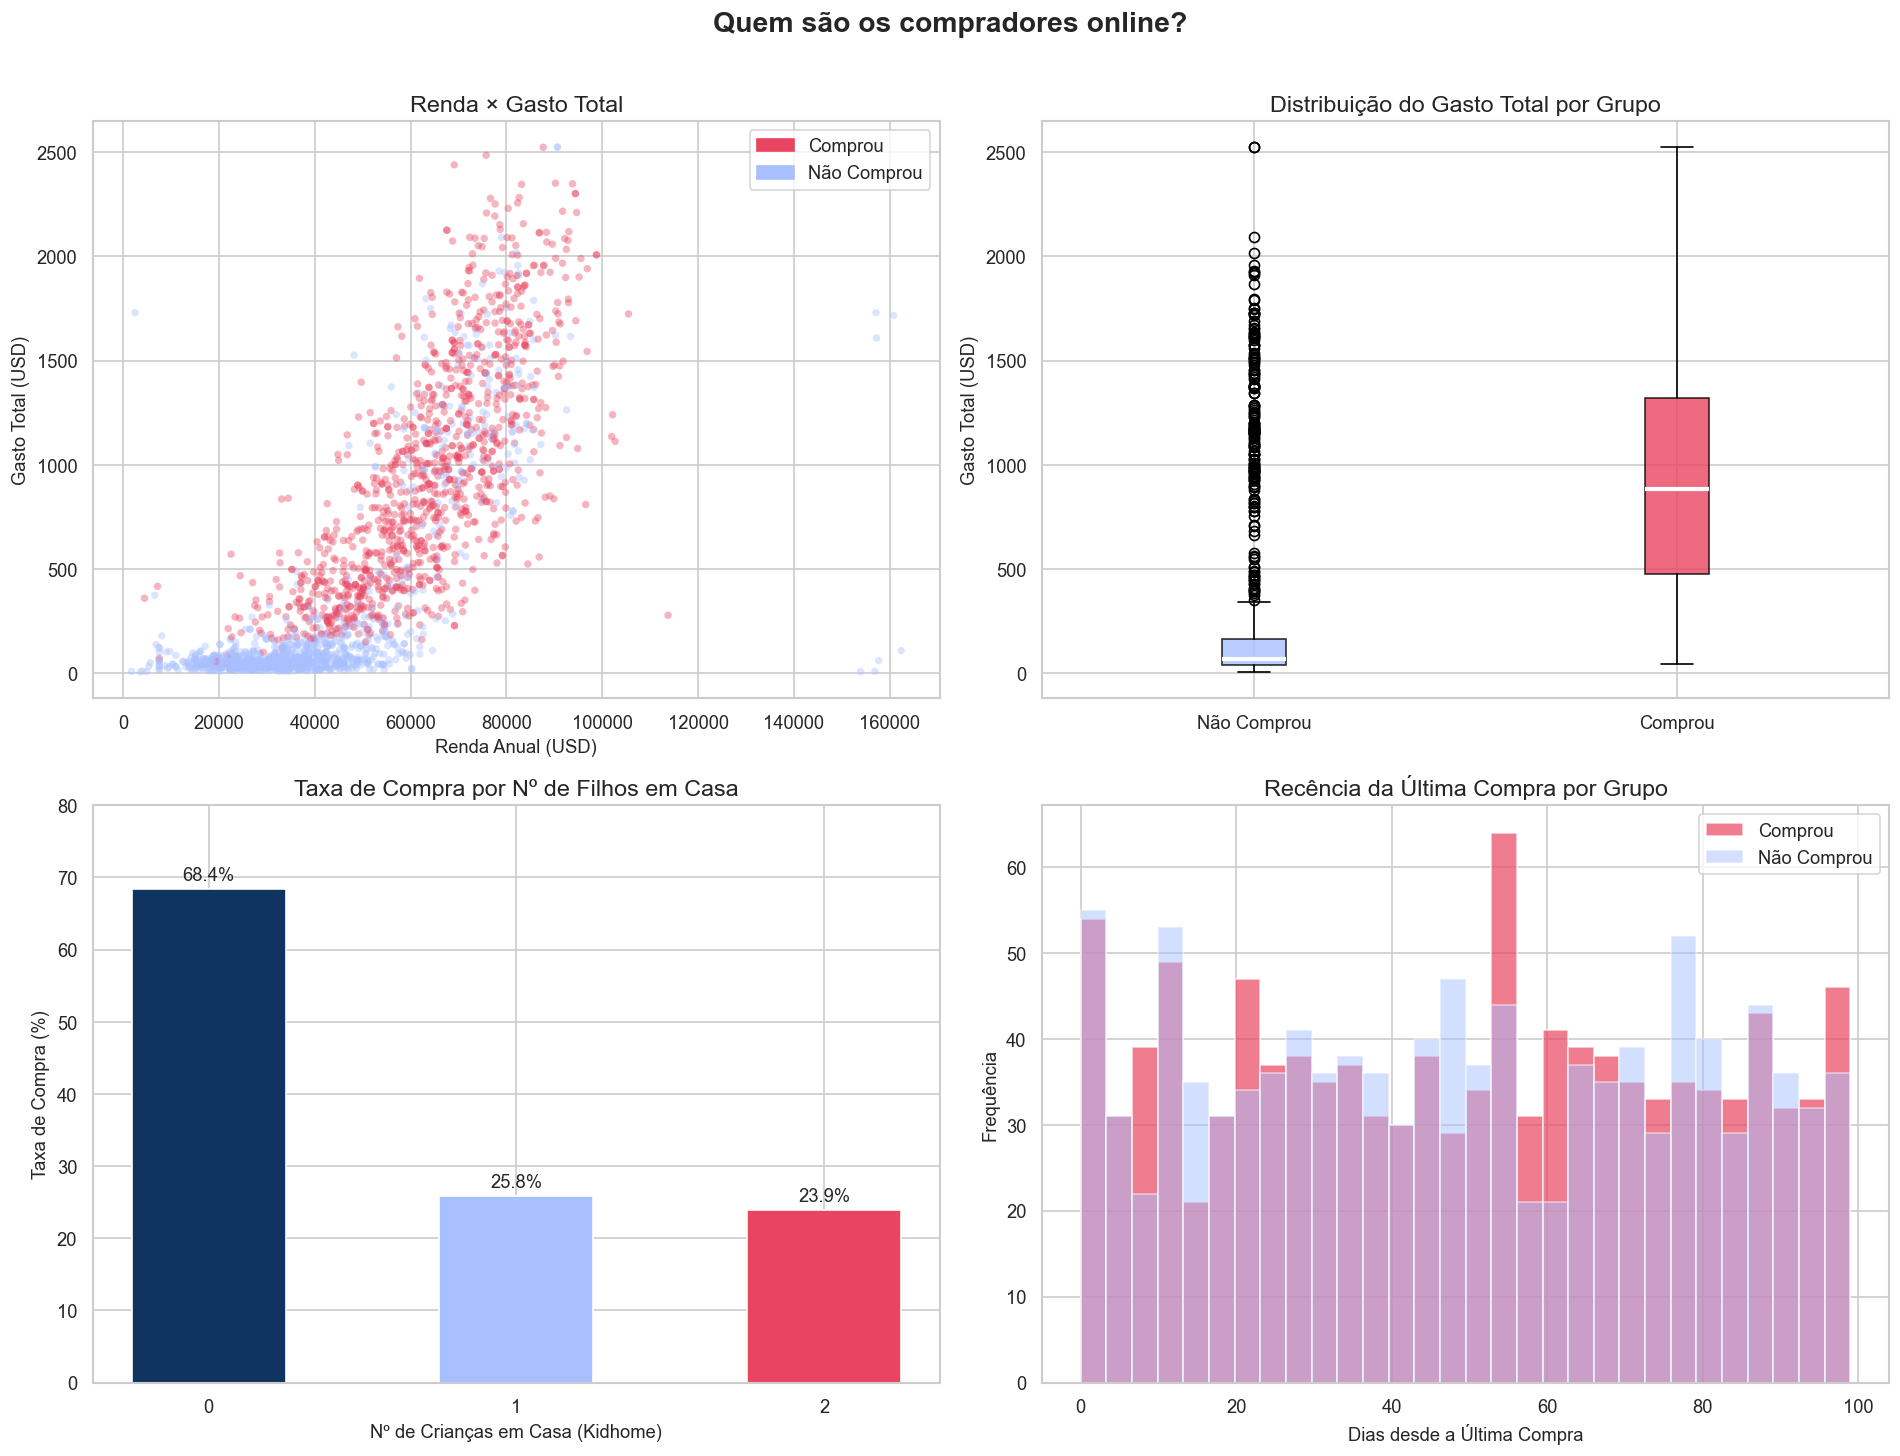


 Insight: Clientes sem filhos têm 68.4% de taxa de compra online.
   Com 1 filho: 25.8% | Com 2 filhos: 23.9%
   Ter filhos em casa reduz drasticamente a propensão de compra online.

 Insight: A recência não distingue bem compradores de não-compradores,
   sugerindo que o comportamento de gasto é mais relevante que o timing.


In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Quem são os compradores online?", fontsize=17, fontweight='bold', y=1.01)

#  Gasto Total vs Renda (scatter)
colors = [PALETTE[1] if x == 1 else PALETTE[2] for x in df_clean['WebPurchases']]
axes[0, 0].scatter(df_clean['Income'], df_clean['Total_Spending'],
                    c=colors, alpha=0.4, s=20, edgecolors='none')
patch1 = mpatches.Patch(color=PALETTE[1], label='Comprou')
patch2 = mpatches.Patch(color=PALETTE[2], label='Não Comprou')
axes[0, 0].legend(handles=[patch1, patch2])
axes[0, 0].set_title("Renda × Gasto Total")
axes[0, 0].set_xlabel("Renda Anual (USD)")
axes[0, 0].set_ylabel("Gasto Total (USD)")

#  Boxplot de gasto por grupo
groups = [df_clean[df_clean['WebPurchases'] == 0]['Total_Spending'],
          df_clean[df_clean['WebPurchases'] == 1]['Total_Spending']]
bp = axes[0, 1].boxplot(groups, patch_artist=True, labels=['Não Comprou', 'Comprou'],
                          medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], [PALETTE[2], PALETTE[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0, 1].set_title("Distribuição do Gasto Total por Grupo")
axes[0, 1].set_ylabel("Gasto Total (USD)")

#  Kidhome e taxa de compra
kid_rate = df_clean.groupby('Kidhome')['WebPurchases'].mean().reset_index()
kid_rate['pct'] = kid_rate['WebPurchases'] * 100
bars = axes[1, 0].bar(kid_rate['Kidhome'].astype(str), kid_rate['pct'],
                        color=[PALETTE[0], PALETTE[2], PALETTE[1]], edgecolor='white', width=0.5)
axes[1, 0].bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
axes[1, 0].set_title("Taxa de Compra por Nº de Filhos em Casa")
axes[1, 0].set_xlabel("Nº de Crianças em Casa (Kidhome)")
axes[1, 0].set_ylabel("Taxa de Compra (%)")
axes[1, 0].set_ylim(0, 80)

#  Recência vs compra
axes[1, 1].hist(df_clean[df_clean['WebPurchases'] == 1]['Recency'],
                 bins=30, alpha=0.7, color=PALETTE[1], label='Comprou')
axes[1, 1].hist(df_clean[df_clean['WebPurchases'] == 0]['Recency'],
                 bins=30, alpha=0.5, color=PALETTE[2], label='Não Comprou')
axes[1, 1].set_title("Recência da Última Compra por Grupo")
axes[1, 1].set_xlabel("Dias desde a Última Compra")
axes[1, 1].set_ylabel("Frequência")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

tax_0 = df_clean[df_clean['Kidhome'] == 0]['WebPurchases'].mean() * 100
tax_1 = df_clean[df_clean['Kidhome'] == 1]['WebPurchases'].mean() * 100
tax_2 = df_clean[df_clean['Kidhome'] == 2]['WebPurchases'].mean() * 100

print(f"\n Insight: Clientes sem filhos têm {tax_0:.1f}% de taxa de compra online.")
print(f"   Com 1 filho: {tax_1:.1f}% | Com 2 filhos: {tax_2:.1f}%")
print(f"   Ter filhos em casa reduz drasticamente a propensão de compra online.")
print(f"\n Insight: A recência não distingue bem compradores de não-compradores,")
print(f"   sugerindo que o comportamento de gasto é mais relevante que o timing.")

### 3.4 — Heatmap de Correlação

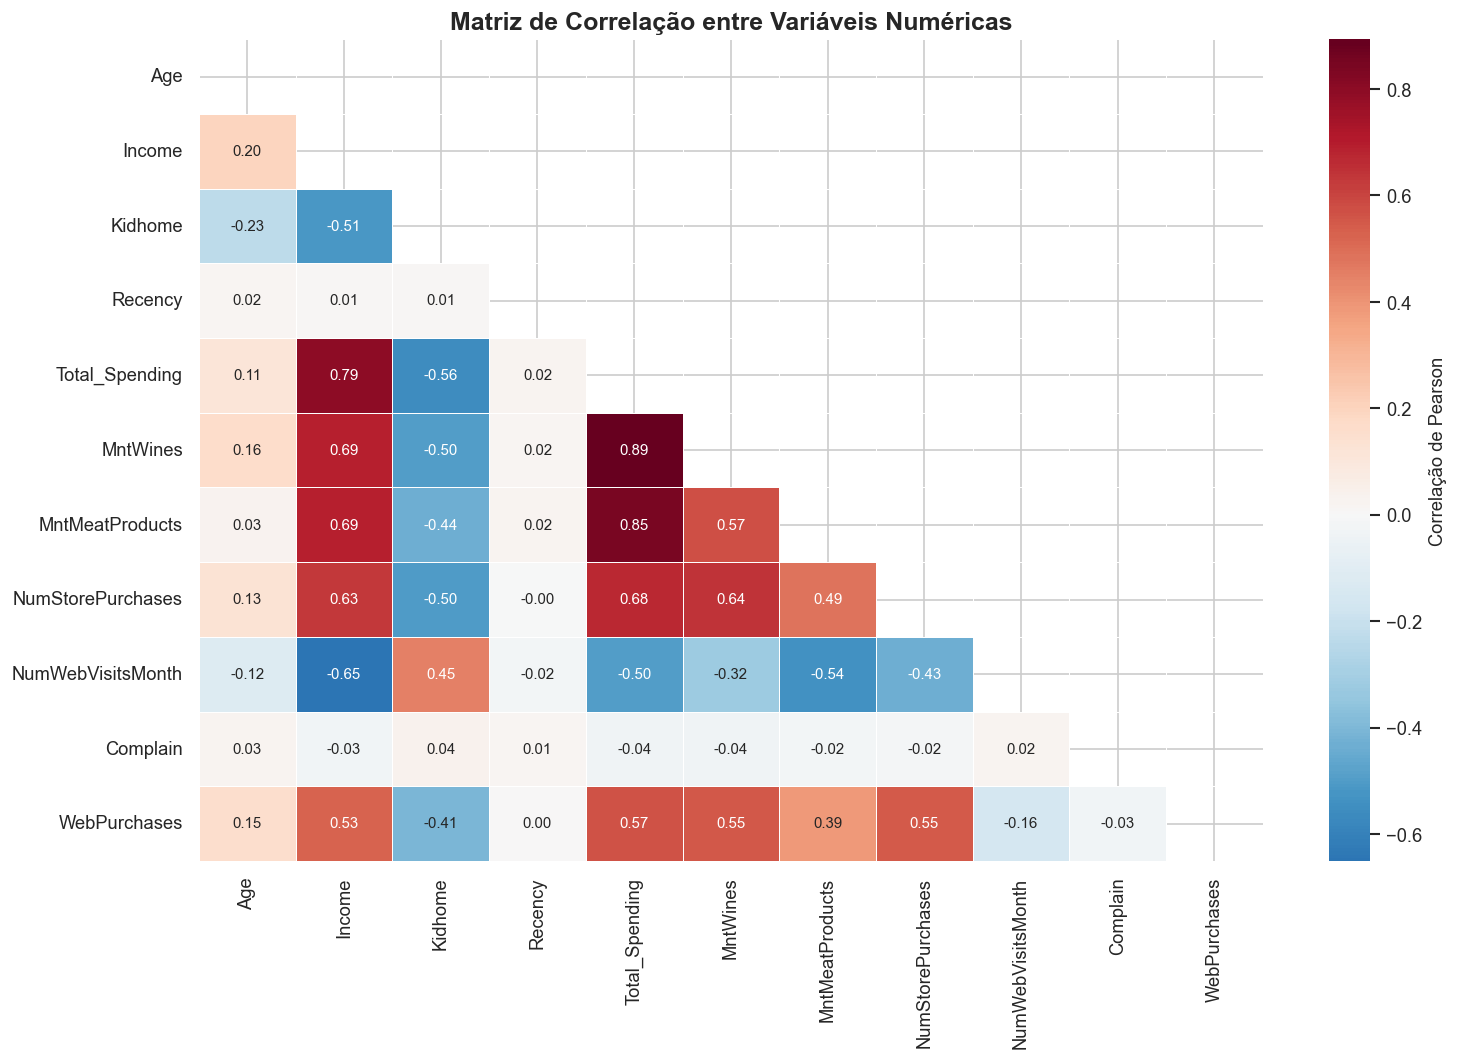


 Insight: As correlações mais fortes com WebPurchases são:
   ↑ Total_Spending: 0.567
   ↑ MntWines: 0.551
   ↑ NumStorePurchases: 0.547
   ↑ Income: 0.528
   ↓ Kidhome: -0.408


In [42]:
plt.figure(figsize=(13, 9))
df_clean['Total_Spending'] = df_clean[mnt_cols].sum(axis=1)

corr = df_clean[['Age', 'Income', 'Kidhome', 'Recency', 'Total_Spending',
                  'MntWines', 'MntMeatProducts', 'NumStorePurchases',
                  'NumWebVisitsMonth', 'Complain', 'WebPurchases']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'Correlação de Pearson'})
plt.title("Matriz de Correlação entre Variáveis Numéricas", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Insight: As correlações mais fortes com WebPurchases são:")
corr_target = corr['WebPurchases'].drop('WebPurchases').sort_values(key=abs, ascending=False)
for feat, val in corr_target.head(5).items():
    direction = '↑' if val > 0 else '↓'
    print(f"   {direction} {feat}: {val:.3f}")

---
<a id='preprocessamento'></a>
## 4.  Pré-processamento

### 4.1  Limpeza e Engenharia de Features

In [43]:
#  Cópia de trabalho
df_model = df.copy()

#  1. Tratamento de outlier de renda
outlier_renda = df_model['Income'] > 200_000
print(f"🔍 Outlier de renda removido: {outlier_renda.sum()} registro(s) com renda > $200k")
df_model = df_model[~outlier_renda].reset_index(drop=True)

#  2. Preenchimento de nulos em Income
nulos_income = df_model['Income'].isnull().sum()
mediana_income = df_model['Income'].median()
df_model['Income'] = df_model['Income'].fillna(mediana_income)
print(f"✏️  {nulos_income} valores nulos em 'Income' preenchidos com a mediana (${mediana_income:,.0f})")

#  3. Feature Engineering
# Idade
df_model['Age'] = 2014 - df_model['Year_Birth']

# Gasto total
mnt_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
df_model['Total_Spending'] = df_model[mnt_cols].sum(axis=1)

# Tem filhos?
df_model['Has_Children'] = (df_model['Kidhome'] > 0).astype(int)

# Total de canais de compra
df_model['Total_Purchases'] = df_model['NumStorePurchases']

print("\n Features criadas:")
print("   • Age            — Idade calculada (2014 - Year_Birth)")
print("   • Total_Spending — Soma de todos os gastos Mnt*")
print("   • Has_Children   — Indicador binário de filhos em casa")
print("   • Total_Purchases— Total de compras em loja física")

print(f"\n Shape após limpeza: {df_model.shape}")

🔍 Outlier de renda removido: 1 registro(s) com renda > $200k
✏️  24 valores nulos em 'Income' preenchidos com a mediana ($51,373)

 Features criadas:
   • Age            — Idade calculada (2014 - Year_Birth)
   • Total_Spending — Soma de todos os gastos Mnt*
   • Has_Children   — Indicador binário de filhos em casa
   • Total_Purchases— Total de compras em loja física

 Shape após limpeza: (2239, 21)


### 4.2 — Encoding, Separação e Normalização

In [44]:
#  Simplificação do estado civil
marital_map = {
    'Married': 'Couple', 'Together': 'Couple',
    'Single': 'Single', 'Divorced': 'Single', 'Widow': 'Single',
    'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single'
}
df_model['Marital_Simple'] = df_model['Marital_Status'].map(marital_map)

#  Seleção de features
features = [
    'Age', 'Income', 'Kidhome', 'Has_Children', 'Recency',
    'Total_Spending', 'MntWines', 'MntMeatProducts', 'MntGoldProds',
    'NumStorePurchases', 'NumWebVisitsMonth', 'Complain',
    'Education', 'Marital_Simple'
]

#  Label Encoding para categóricas
le_edu = LabelEncoder()
le_ms  = LabelEncoder()
df_model['Education_enc']      = le_edu.fit_transform(df_model['Education'])
df_model['Marital_Simple_enc'] = le_ms.fit_transform(df_model['Marital_Simple'])

features_num = [f for f in features if f not in ['Education', 'Marital_Simple']]
features_num += ['Education_enc', 'Marital_Simple_enc']

print("Features selecionadas para modelagem:")
for f in features_num:
    print(f"  • {f}")

Features selecionadas para modelagem:
  • Age
  • Income
  • Kidhome
  • Has_Children
  • Recency
  • Total_Spending
  • MntWines
  • MntMeatProducts
  • MntGoldProds
  • NumStorePurchases
  • NumWebVisitsMonth
  • Complain
  • Education_enc
  • Marital_Simple_enc


In [45]:
#  Separação X e y
X = df_model[features_num]
y = df_model['WebPurchases']

#  Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Divisão treino/teste:")
print(f"   Treino : {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Teste  : {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n Balanço de classes no treino:")
print(f"   Comprou     : {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")
print(f"   Não Comprou : {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")

#  Padronização
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\n Dados padronizados (StandardScaler)")
print(f"   Média de Age (antes): {X_train['Age'].mean():.1f}")
print(f"   Média de Age (após) : ~0 (padronizado)")

 Divisão treino/teste:
   Treino : 1,791 amostras (80%)
   Teste  : 448 amostras (20%)

 Balanço de classes no treino:
   Comprou     : 902 (50.4%)
   Não Comprou : 889 (49.6%)

 Dados padronizados (StandardScaler)
   Média de Age (antes): 45.1
   Média de Age (após) : ~0 (padronizado)


---
<a id='modelagem'></a>
## 5.  Modelagem

Vamos comparar dois algoritmos de ensemble amplamente utilizados para classificação binária:

| Modelo | Por que usar? |
|--------|--------------|
| **Random Forest** | Robusto, interpreta bem dados tabulares, resistente a overfitting via bagging |
| **XGBoost** | Boosting com regularização, costuma superar outros modelos em competições |

In [46]:
#  Random Forest
print(" Treinando Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                              min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf   = rf.predict(X_test_s)
y_proba_rf  = rf.predict_proba(X_test_s)[:, 1]

# Cross-validation no treino
cv_rf = cross_val_score(rf, X_train_s, y_train, cv=5, scoring='f1')
print(f"   CV F1-Score (5 folds): {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")

#  XGBoost
print("\n⚡ Treinando XGBoost...")
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                     subsample=0.8, colsample_bytree=0.8,
                     eval_metric='logloss', random_state=42, verbosity=0)
xgb.fit(X_train_s, y_train)
y_pred_xgb  = xgb.predict(X_test_s)
y_proba_xgb = xgb.predict_proba(X_test_s)[:, 1]

cv_xgb = cross_val_score(xgb, X_train_s, y_train, cv=5, scoring='f1')
print(f"   CV F1-Score (5 folds): {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

print("\n Modelos treinados!")

 Treinando Random Forest...
   CV F1-Score (5 folds): 0.909 ± 0.017

⚡ Treinando XGBoost...
   CV F1-Score (5 folds): 0.918 ± 0.011

 Modelos treinados!


---
<a id='avaliacao'></a>
## 6.  Avaliação dos Modelos

In [47]:
#  Função auxiliar de métricas
def get_metrics(y_true, y_pred, y_proba, name):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return {
        'Modelo'    : name,
        'Acurácia'  : accuracy_score(y_true, y_pred),
        'Precisão'  : precision_score(y_true, y_pred),
        'Recall'    : recall_score(y_true, y_pred),
        'F1-Score'  : f1_score(y_true, y_pred),
        'AUC-ROC'   : auc(fpr, tpr),
        '_fpr'      : fpr,
        '_tpr'      : tpr,
    }

m_rf  = get_metrics(y_test, y_pred_rf,  y_proba_rf,  'Random Forest')
m_xgb = get_metrics(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost')

#  Tabela comparativa
metricas = pd.DataFrame([m_rf, m_xgb]).set_index('Modelo')
metricas_show = metricas[['Acurácia','Precisão','Recall','F1-Score','AUC-ROC']]

print("             COMPARATIVO DE MÉTRICAS")

display(metricas_show.style
        .format("{:.4f}")
        .background_gradient(cmap='Blues', axis=0)
        .set_caption("Métricas calculadas no conjunto de teste"))

             COMPARATIVO DE MÉTRICAS


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Random Forest,0.9062,0.8622,0.9690,0.9125,0.9787
XGBoost,0.9286,0.8943,0.9735,0.9322,0.9791


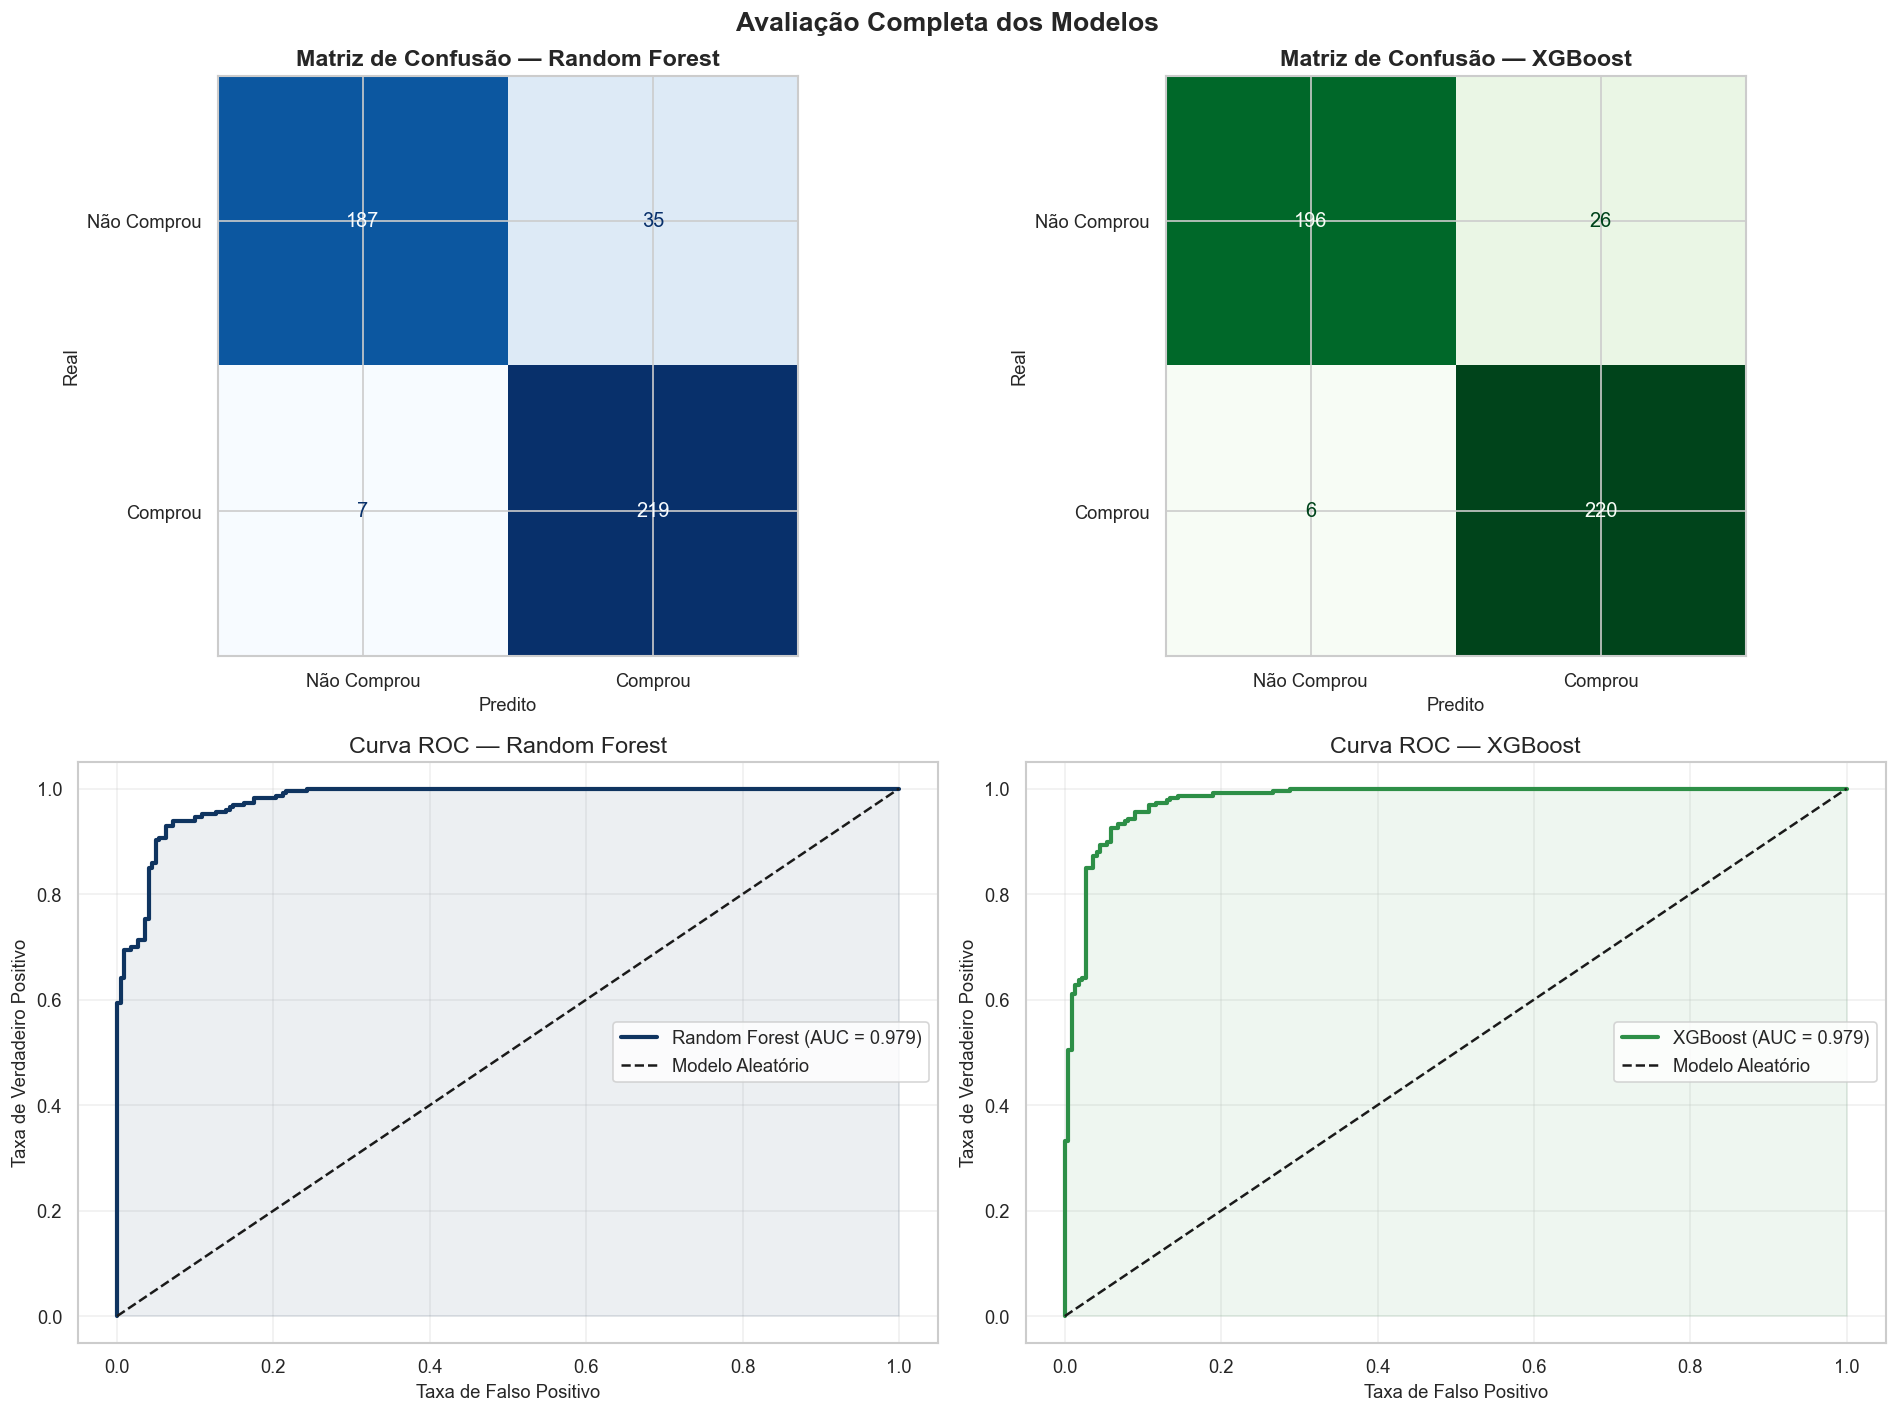

In [48]:
#  Visualizações: Matrizes de Confusão + Curvas ROC
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Avaliação Completa dos Modelos", fontsize=16, fontweight='bold')

# Matrizes de Confusão
for ax, model, y_pred, name, cmap in [
    (axes[0, 0], rf,  y_pred_rf,  'Random Forest', 'Blues'),
    (axes[0, 1], xgb, y_pred_xgb, 'XGBoost',       'Greens')
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Não Comprou', 'Comprou'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f"Matriz de Confusão — {name}", fontweight='bold')
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

# Curva ROC — RF
fpr_rf, tpr_rf = m_rf['_fpr'], m_rf['_tpr']
axes[1, 0].plot(fpr_rf, tpr_rf, color=PALETTE[0], lw=2.5, label=f"Random Forest (AUC = {m_rf['AUC-ROC']:.3f})")
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Modelo Aleatório')
axes[1, 0].fill_between(fpr_rf, tpr_rf, alpha=0.08, color=PALETTE[0])
axes[1, 0].set_title("Curva ROC — Random Forest")
axes[1, 0].set_xlabel("Taxa de Falso Positivo")
axes[1, 0].set_ylabel("Taxa de Verdadeiro Positivo")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Curva ROC — XGB
fpr_xgb, tpr_xgb = m_xgb['_fpr'], m_xgb['_tpr']
axes[1, 1].plot(fpr_xgb, tpr_xgb, color='#2d8f47', lw=2.5, label=f"XGBoost (AUC = {m_xgb['AUC-ROC']:.3f})")
axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Modelo Aleatório')
axes[1, 1].fill_between(fpr_xgb, tpr_xgb, alpha=0.08, color='#2d8f47')
axes[1, 1].set_title("Curva ROC — XGBoost")
axes[1, 1].set_xlabel("Taxa de Falso Positivo")
axes[1, 1].set_ylabel("Taxa de Verdadeiro Positivo")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
#  Relatório detalhado
print("   RELATÓRIO DETALHADO — RANDOM FOREST")

print(classification_report(y_test, y_pred_rf,
      target_names=['Não Comprou (0)', 'Comprou (1)']))

print("   RELATÓRIO DETALHADO — XGBOOST")

print(classification_report(y_test, y_pred_xgb,
      target_names=['Não Comprou (0)', 'Comprou (1)']))

   RELATÓRIO DETALHADO — RANDOM FOREST
                 precision    recall  f1-score   support

Não Comprou (0)       0.96      0.84      0.90       222
    Comprou (1)       0.86      0.97      0.91       226

       accuracy                           0.91       448
      macro avg       0.91      0.91      0.91       448
   weighted avg       0.91      0.91      0.91       448

   RELATÓRIO DETALHADO — XGBOOST
                 precision    recall  f1-score   support

Não Comprou (0)       0.97      0.88      0.92       222
    Comprou (1)       0.89      0.97      0.93       226

       accuracy                           0.93       448
      macro avg       0.93      0.93      0.93       448
   weighted avg       0.93      0.93      0.93       448



---
<a id='features'></a>
## 7.  Feature Importance — O que mais influencia a compra?

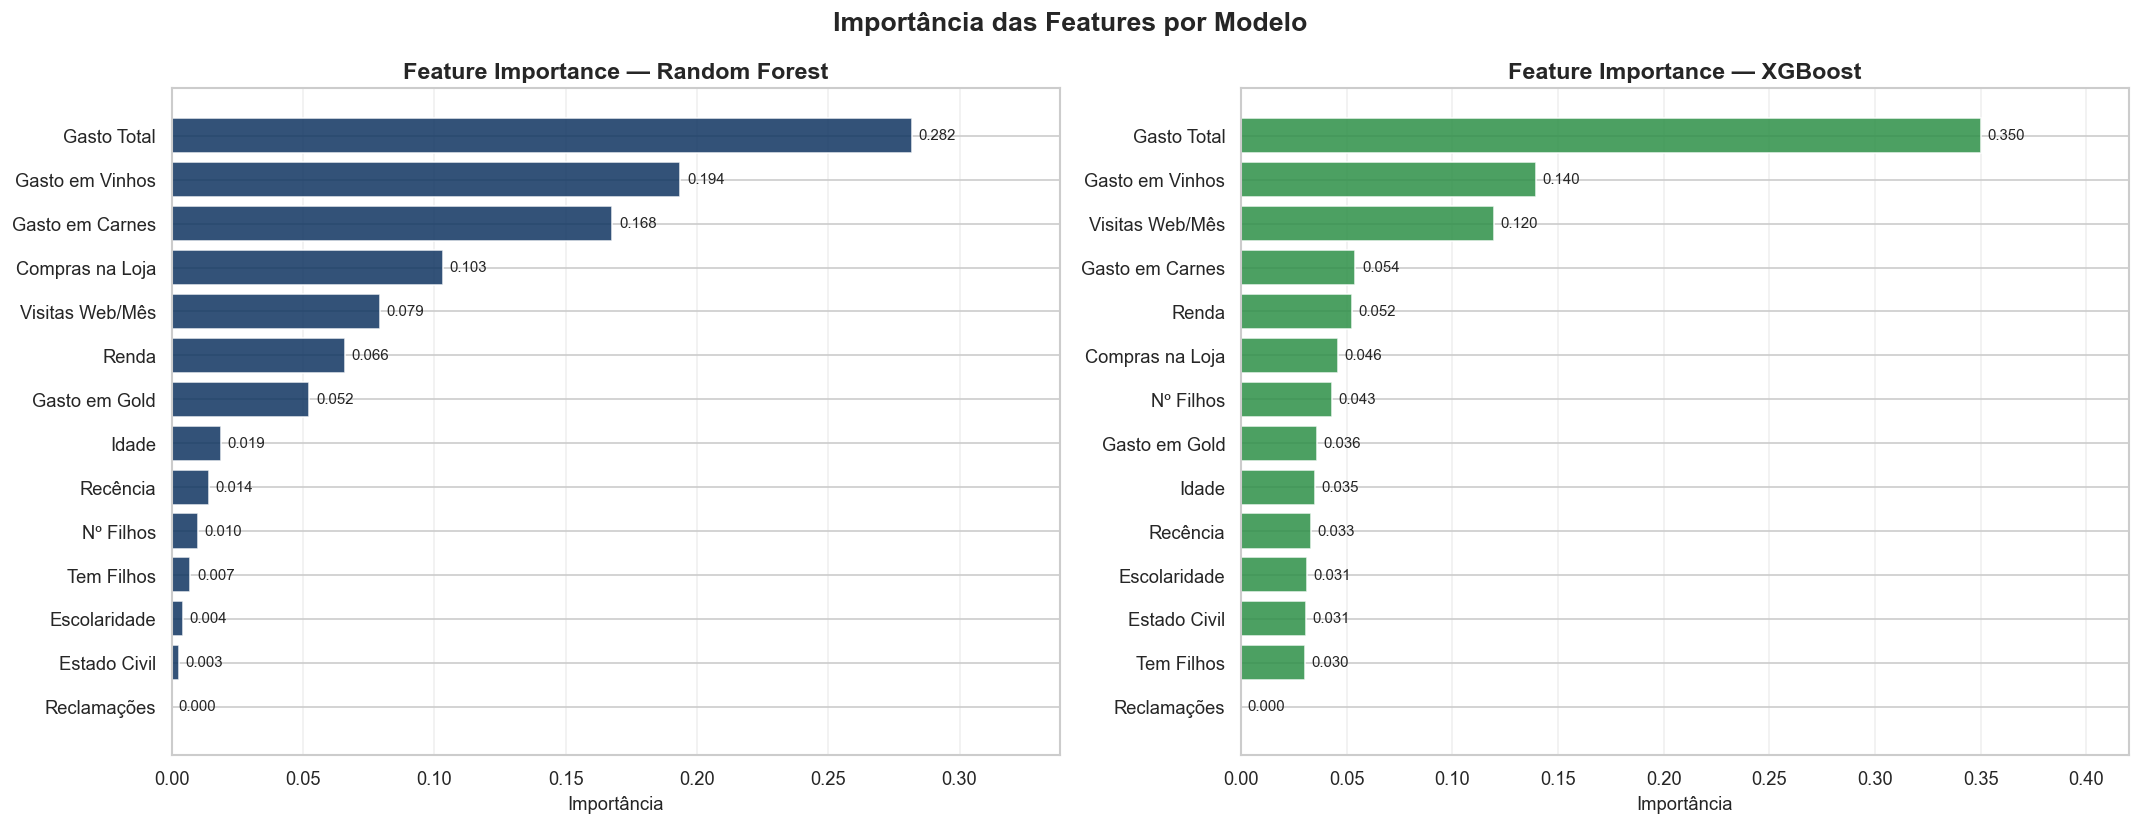


💡 Top 3 features mais importantes (Random Forest):
   1. Gasto Total: 0.282
   2. Gasto em Vinhos: 0.194
   3. Gasto em Carnes: 0.168


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Importância das Features por Modelo", fontsize=16, fontweight='bold')

#  Nome legível das features
feat_names_map = {
    'Age': 'Idade',
    'Income': 'Renda',
    'Kidhome': 'Nº Filhos',
    'Has_Children': 'Tem Filhos',
    'Recency': 'Recência',
    'Total_Spending': 'Gasto Total',
    'MntWines': 'Gasto em Vinhos',
    'MntMeatProducts': 'Gasto em Carnes',
    'MntGoldProds': 'Gasto em Gold',
    'NumStorePurchases': 'Compras na Loja',
    'NumWebVisitsMonth': 'Visitas Web/Mês',
    'Complain': 'Reclamações',
    'Education_enc': 'Escolaridade',
    'Marital_Simple_enc': 'Estado Civil'
}

feat_labels = [feat_names_map.get(f, f) for f in features_num]

for ax, model, name, color in [
    (axes[0], rf,  'Random Forest', PALETTE[0]),
    (axes[1], xgb, 'XGBoost',       '#2d8f47')
]:
    importances = pd.Series(model.feature_importances_, index=feat_labels)
    importances = importances.sort_values(ascending=True)
    bars = ax.barh(importances.index, importances.values, color=color, edgecolor='white', alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.set_title(f"Feature Importance — {name}", fontweight='bold')
    ax.set_xlabel("Importância")
    ax.set_xlim(0, importances.max() * 1.2)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Top 3 features
imp_rf = pd.Series(rf.feature_importances_, index=feat_labels).sort_values(ascending=False)
print("\n💡 Top 3 features mais importantes (Random Forest):")
for i, (feat, val) in enumerate(imp_rf.head(3).items(), 1):
    print(f"   {i}. {feat}: {val:.3f}")

---
<a id='conclusao'></a>
## 8.  Conclusão

### 8.1 — Resumo dos Resultados

In [51]:

print("               RESUMO EXECUTIVO DO PROJETO")


rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_f1   = f1_score(y_test, y_pred_rf)
rf_auc  = m_rf['AUC-ROC']
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb)
xgb_auc = m_xgb['AUC-ROC']

melhor = 'Random Forest' if rf_f1 >= xgb_f1 else 'XGBoost'
melhor_f1 = max(rf_f1, xgb_f1)

print(f"\n MODELO VENCEDOR: {melhor}")
print(f"   F1-Score : {melhor_f1:.4f}")
print(f"   AUC-ROC  : {max(rf_auc, xgb_auc):.4f}")
print(f"\n Comparativo:")
print(f"   {'Modelo':<20} {'Acurácia':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print(f"   {'-'*52}")
print(f"   {'Random Forest':<20} {rf_acc:>10.4f} {rf_f1:>10.4f} {rf_auc:>10.4f}")
print(f"   {'XGBoost':<20} {xgb_acc:>10.4f} {xgb_f1:>10.4f} {xgb_auc:>10.4f}")

# Falsos negativos (clientes que comprariam e não foram identificados)
cm_rf = confusion_matrix(y_test, y_pred_rf)
fn = cm_rf[1, 0]
tp = cm_rf[1, 1]
print(f"\n  Análise de erros do modelo vencedor:")
print(f"   Compradores corretamente identificados: {tp}")
print(f"   Compradores perdidos (falsos negativos): {fn}")
print(f"   Taxa de captura: {tp/(tp+fn)*100:.1f}% dos compradores reais")

               RESUMO EXECUTIVO DO PROJETO

 MODELO VENCEDOR: XGBoost
   F1-Score : 0.9322
   AUC-ROC  : 0.9791

 Comparativo:
   Modelo                 Acurácia   F1-Score    AUC-ROC
   ----------------------------------------------------
   Random Forest            0.9062     0.9125     0.9787
   XGBoost                  0.9286     0.9322     0.9791

  Análise de erros do modelo vencedor:
   Compradores corretamente identificados: 219
   Compradores perdidos (falsos negativos): 7
   Taxa de captura: 96.9% dos compradores reais


### 8.2 — Insights de Negócio

---

####  O que o modelo aprendeu:

1. **Gasto Total e Renda são os fatores mais determinantes** para prever compras online. Clientes com maior renda e histórico de gastos elevados convertem muito mais.

2. **Filhos em casa reduzem a propensão de compra online** — provavelmente pela mudança nas prioridades de consumo (gastam menos em categorias premium).

3. **A recência não é um bom discriminador** — tanto compradores quanto não-compradores apresentam distribuições similares de tempo desde a última compra.

4. **Vinhos são a categoria âncora** — responde por mais da metade do gasto médio total. Campanhas de cross-sell devem partir desse produto.

---

####  Recomendações de Negócio:

| Ação | Público-alvo | Justificativa |
|------|-------------|---------------|
| Campanha premium de vinhos | Score alto no modelo + sem filhos | Maior propensão de compra + maior ticket |
| Retenção com desconto | Score médio + com filhos | Evitar churn de clientes em transição de vida |
| A/B Test canal web vs loja | Clientes com alto `NumStorePurchases` | Migrar compradores físicos para digital |

---

####  Próximos Passos (para evoluir o modelo):

- [ ] Otimização de hiperparâmetros com `GridSearchCV` ou `Optuna`
- [ ] Balanceamento de classes com SMOTE (se o dataset for mais desbalanceado em produção)
- [ ] Deploy via API (FastAPI + Pickle) para scoring em tempo real
- [ ] Monitoramento de data drift com Evidently ou Alibi

---

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #0f3460 100%); padding: 25px; border-radius: 10px; text-align: center; color: white; margin-top: 20px;">
  <h3 style="color: #a8c0ff; margin: 0;">📌 Projeto Módulo 37 — Concluído</h3>
  <p style="color: #ccc; margin: 10px 0 0 0;">
    Dataset: <code>marketing_campaign.csv</code> | 
    Modelos: Random Forest & XGBoost | 
    Target: WebPurchases
  </p>
</div>